In [1]:
import csv
import pandas as pd

In [2]:
params = {
    'fileLocation': 'database\\winemag-data-130k-v2_clean.csv',
}

In [3]:
df = csv.reader(open(params['fileLocation'], 'r', encoding='utf-8'))
columns = next(df)
columns[0] = 'id'  # Az első oszlop neve 'id' legyen
df = pd.DataFrame(df, columns=columns)

print(df.shape)
display(df.head())

(129971, 7)


,id,country,description,points,province,region_1,region_2
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",87,Sicily & Sardinia,Etna,
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",87,Douro,,
2,2,US,"Tart and snappy, the flavors of lime flesh and...",87,Oregon,Willamette Valley,Willamette Valley
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",87,Michigan,Lake Michigan Shore,
4,4,US,"Much like the regular bottling from 2012, this...",87,Oregon,Willamette Valley,Willamette Valley


In [8]:
df_description = df[['id', 'country', 'points', 'province', 'region_1', 'region_2']].copy()
# df_description.head(5)

df_description['group'] = pd.qcut(df_description['points'].astype(int),
                                 q=4,
                                 labels=['poor', 'below_avg', 'above_avg', 'excellent'])

# display(df_description['group'].value_counts())
display(df_description.head(5))

,id,country,points,province,region_1,region_2,group
0,0,Italy,87,Sicily & Sardinia,Etna,,below_avg
1,1,Portugal,87,Douro,,,below_avg
2,2,US,87,Oregon,Willamette Valley,Willamette Valley,below_avg
3,3,US,87,Michigan,Lake Michigan Shore,,below_avg
4,4,US,87,Oregon,Willamette Valley,Willamette Valley,below_avg


## Adatok megismerése

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Alapvető statisztikák
print(f"Adatbázis mérete: {df.shape}")
print("\nHiányzó adatok száma:")
print(df.isnull().sum())

Adatbázis mérete: (129971, 7)

Hiányzó adatok száma:
id             0
country        0
description    0
points         0
province       0
region_1       0
region_2       0
dtype: int64


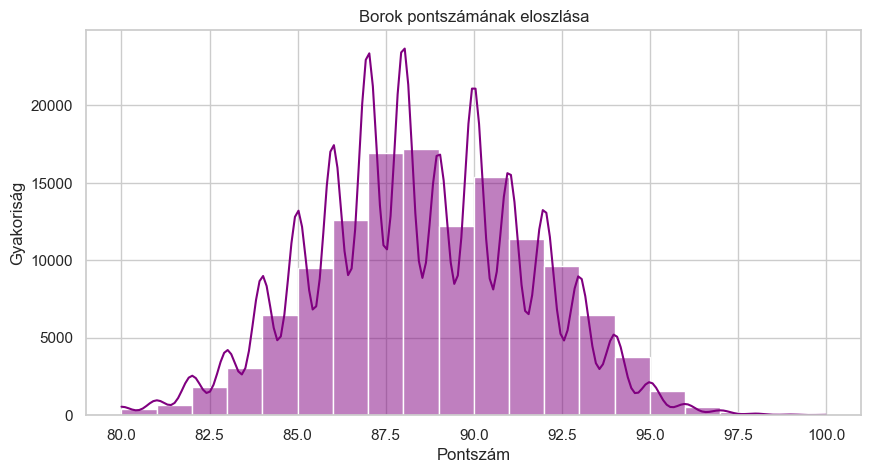

Átlagos pontszám: 88.45
Leggyakoribb pontszám: 88


In [10]:
# 2. Pontszámok eloszlása
plt.figure(figsize=(10, 5))
# Mivel a csv olvasáskor minden string lehet, konvertáljuk int-re
sns.histplot(df['points'].astype(int), bins=20, kde=True, color='purple')
plt.title('Borok pontszámának eloszlása')
plt.xlabel('Pontszám')
plt.ylabel('Gyakoriság')
plt.show()

print(f"Átlagos pontszám: {df['points'].astype(int).mean():.2f}")
print(f"Leggyakoribb pontszám: {df['points'].astype(int).mode()[0]}")

Összesen 44 különböző ország található.


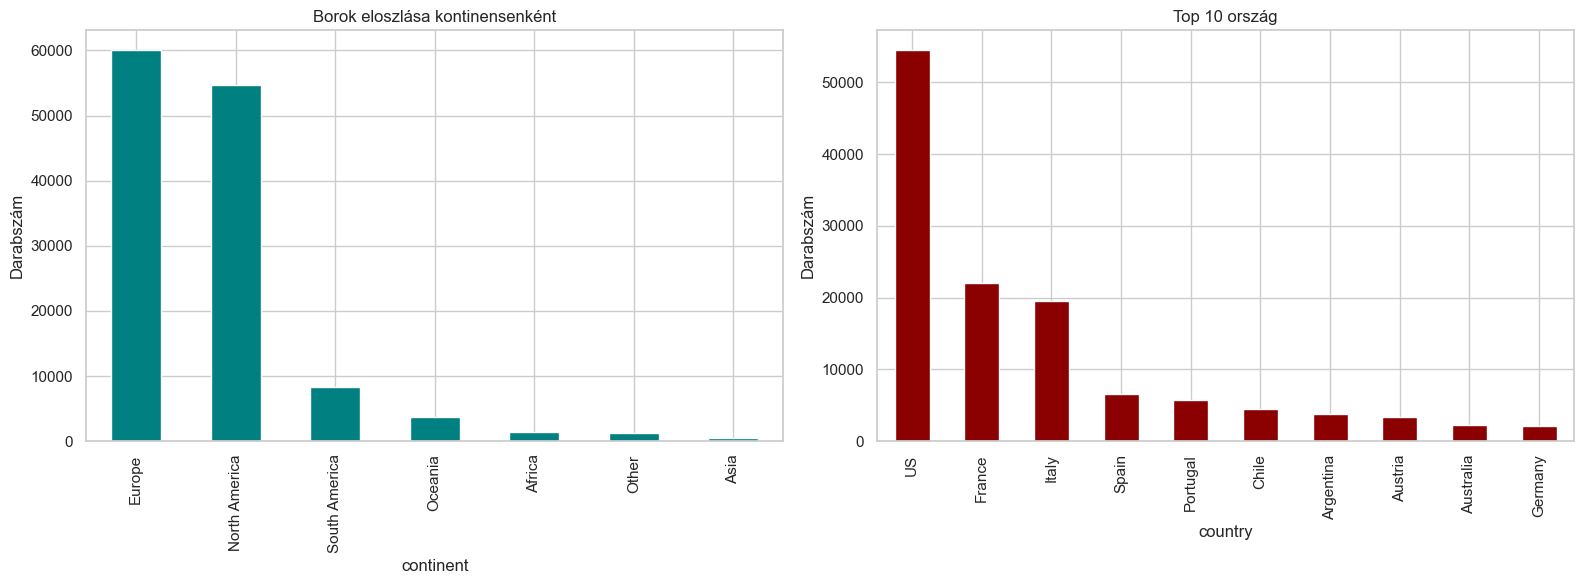

In [11]:
# 3. Országok és Kontinensek
# Egyszerű kontinens leképezés a főbb bortermelő országokra
continent_map = {
    'US': 'North America', 'France': 'Europe', 'Italy': 'Europe', 'Spain': 'Europe', 
    'Portugal': 'Europe', 'Chile': 'South America', 'Argentina': 'South America', 
    'Australia': 'Oceania', 'Austria': 'Europe', 'Germany': 'Europe', 
    'New Zealand': 'Oceania', 'South Africa': 'Africa', 'Israel': 'Asia', 
    'Greece': 'Europe', 'Canada': 'North America', 'Hungary': 'Europe'
}

# Új oszlop a vizualizációhoz (ahol nincs megadva, ott 'Other')
df['continent'] = df['country'].map(continent_map).fillna('Other')

print(f"Összesen {df['country'].nunique()} különböző ország található.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kontinensek
df['continent'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Borok eloszlása kontinensenként')
axes[0].set_ylabel('Darabszám')

# Top 10 Ország
df['country'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='darkred')
axes[1].set_title('Top 10 ország')
axes[1].set_ylabel('Darabszám')

plt.tight_layout()
plt.show()

Különböző tartományok (Province) száma: 426


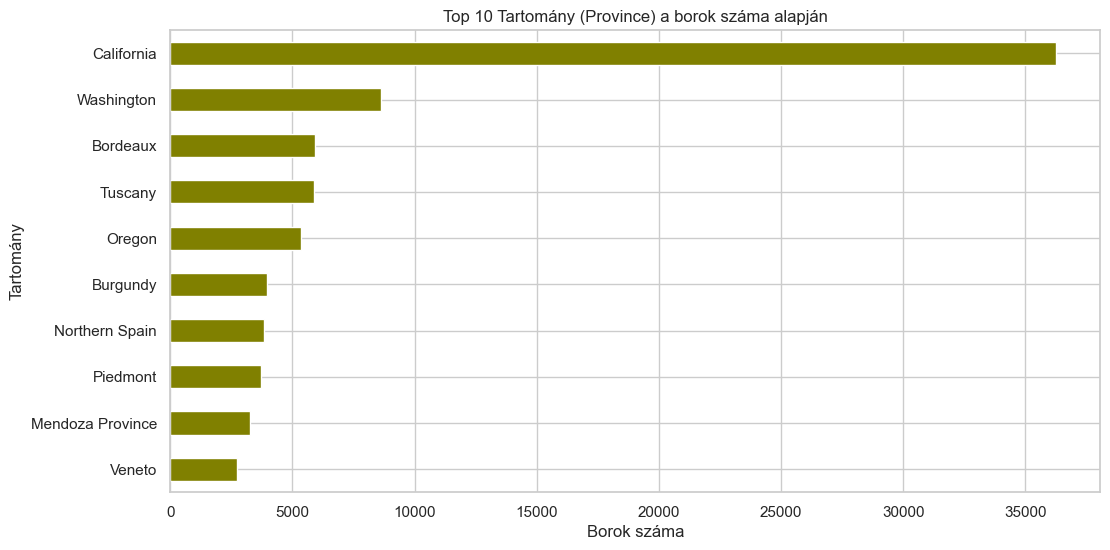

In [12]:
# 4. Régiók és Tartományok eloszlása
print(f"Különböző tartományok (Province) száma: {df['province'].nunique()}")

# Top 10 Tartomány
plt.figure(figsize=(12, 6))
df['province'].value_counts().head(10).plot(kind='barh', color='olive')
plt.title('Top 10 Tartomány (Province) a borok száma alapján')
plt.xlabel('Borok száma')
plt.ylabel('Tartomány')
plt.gca().invert_yaxis()
plt.show()

Összefüggés keresése

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Beállítások a szebb grafikonokért
sns.set_theme(style="whitegrid")

# Biztosítjuk, hogy a points oszlop numerikus legyen a vizualizációhoz
df_description['points'] = df_description['points'].astype(int)

# 1. Országok szerinti átlagos pontszám vizsgálata
# Csak azok az országok, ahol van elég adat (pl. több  mint 100 értékelés), hogy elkerüljük a torzítást
country_counts = df_description['country'].value_counts()
valid_countries = country_counts[country_counts > 100].index
df_filtered_country = df_description[df_description['country'].isin(valid_countries)]

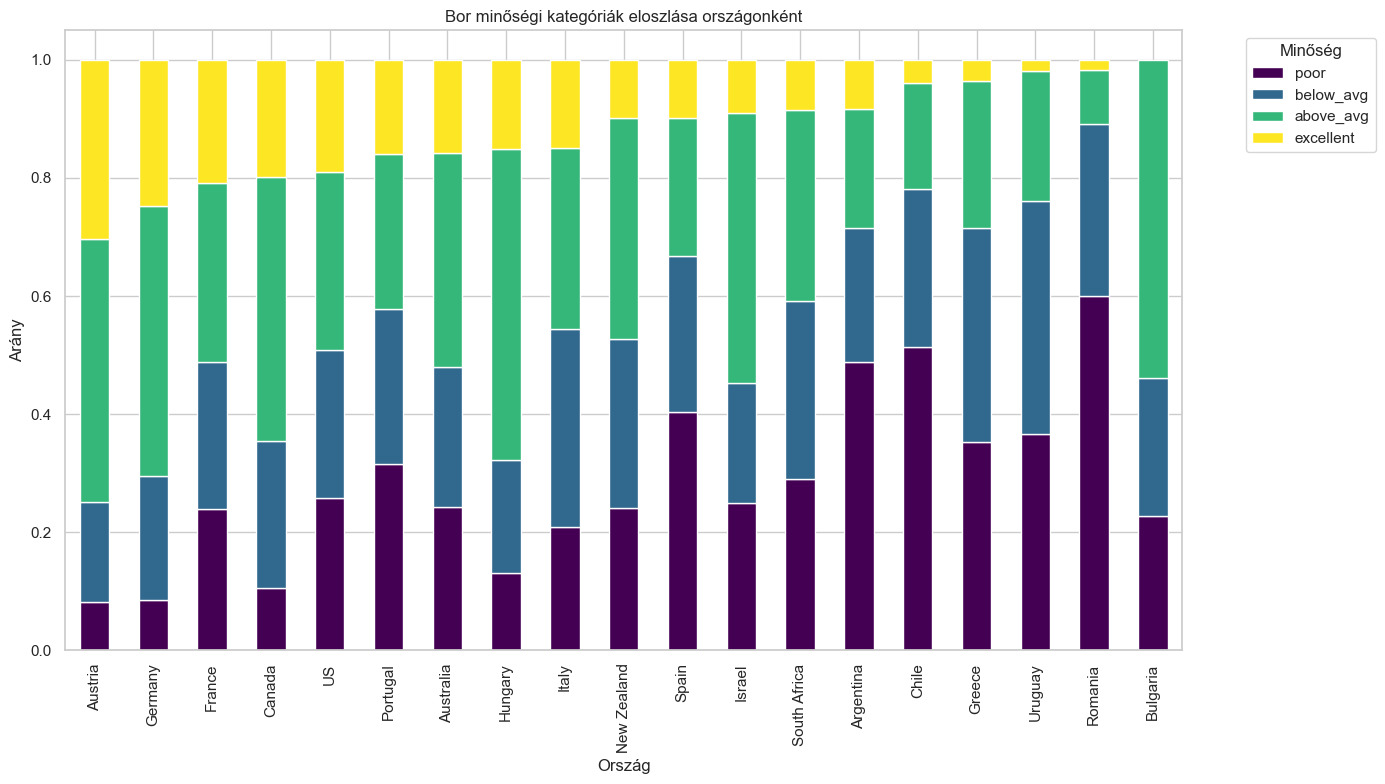

In [14]:
# 2. Minőségi kategóriák eloszlása országonként
# Ez megmutatja, hogy egy adott országból származó bor mekkora eséllyel esik egy bizonyos minőségi kategóriába

# Kereszttábla készítése és normalizálása (százalékos eloszlás)
ct = pd.crosstab(df_filtered_country['country'], df_filtered_country['group'], normalize='index')

# Rendezés: azon országok kerüljenek előre, ahol a legnagyobb az "excellent" borok aránya
ct = ct.reindex(ct.sort_values(by='excellent', ascending=False).index)

# Stacked bar chart
ct.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis')
plt.title('Bor minőségi kategóriák eloszlása országonként')
plt.ylabel('Arány')
plt.xlabel('Ország')
plt.legend(title='Minőség', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()